# Project 3 · The Latent Laboratory

**Fashion-MNIST · PyTorch · compression · neighborhoods · interpolation**

Train one autoencoder family, then investigate three questions:

1. What survives when the latent dimension is small?
2. Which examples become neighbors, and how does this change with dimension?
3. What does the decoder produce between two encoded images?

Implement the five marked tasks. Data loading, optimization, PCA displays,
plotting, widgets, and exports are provided infrastructure. Labels never enter
the reconstruction loss. Complete the written investigations as well as the code.
The expected results below come from one reference run; they are not numerical
targets you must match exactly. CPU/GPU and library differences affect training.

**Colab:** choose a GPU runtime if available. Locally, install `torch`,
`torchvision`, `numpy`, `matplotlib`, and `ipywidgets` in your environment.
The notebook downloads Fashion-MNIST on first use. It requires no course files.

In [ ]:
import os, json, random, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import FashionMNIST
from torchvision.transforms import ToTensor

SEED = 41
DIMS = (2, 8, 32, 128)
EPOCHS = 6             # use 1 for debugging, then restore 6 for every d
BATCH_SIZE = 256
LR = 1e-3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR = Path(os.environ.get('COURSE_DATA_DIR', 'data'))
OUT = Path(os.environ.get('COURSE_OUTPUT_DIR', 'latent-results'))
OUT.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR = Path(os.environ.get('COURSE_CHECKPOINT_DIR', str(OUT/'checkpoints')))
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
torch.set_num_threads(min(4, os.cpu_count() or 1))

def seed_all(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

seed_all(SEED)
print('device:', DEVICE, '| torch:', torch.__version__)

## 1 · Download, split, and inspect

Fashion-MNIST contains 28×28 grayscale garment images. We split its 60,000
training examples into 50,000 fitting and 10,000 validation examples using a
fixed permutation. The official 10,000 test images remain untouched until the
final evaluation cell. Use validation images for every dimension comparison,
map, neighbor investigation, and interpolation experiment.

`Subset` stores indices referring to the same underlying dataset, not copied
image tensors. Each DataLoader obtains batches through those references:

```text
full_train: 60,000 images + labels
  ├── train_set: 50,000 indices ──> shuffled training batches
  └── val_set:   10,000 indices ──> ordered validation batches
official test_set: 10,000 images ──> final evaluation only

Autoencoder(nn.Module)
  ├── encoder: owns Flatten + Linear/ReLU layers  ──> z
  └── decoder: owns Linear/ReLU + Sigmoid/Unflatten ──> x_hat

models[d] references a separately trained Autoencoder for that dimension.
histories[d] contains its measured epoch losses, not another model.
```

In [ ]:
full_train = FashionMNIST(DATA_DIR, train=True, download=True, transform=ToTensor())
test_set = FashionMNIST(DATA_DIR, train=False, download=True, transform=ToTensor())
order = torch.randperm(len(full_train), generator=torch.Generator().manual_seed(SEED))
train_ids, val_ids = order[:50000], order[50000:]
train_set = Subset(full_train, train_ids.tolist())
val_set = Subset(full_train, val_ids.tolist())
class_names = full_train.classes
assert len(set(train_ids.tolist()) & set(val_ids.tolist())) == 0
assert len(train_set) == 50000 and len(val_set) == len(test_set) == 10000

def train_loader():
    # A fresh generator gives each d the same batch order for the same epoch.
    return DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                      generator=torch.Generator().manual_seed(SEED), num_workers=0)

val_loader = DataLoader(val_set, batch_size=512, shuffle=False, num_workers=0)
val_labels = full_train.targets[val_ids]
# Balanced inspection subset; no label is given to the model.
inspect_ids = torch.cat([(val_labels == k).nonzero().flatten()[:100] for k in range(10)])
inspect_set = Subset(val_set, inspect_ids.tolist())
inspect_loader = DataLoader(inspect_set, batch_size=256, shuffle=False)

def savefig(fig, name):
    fig.savefig(OUT / name, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

def image_grid(rows, row_labels, titles, name):
    fig, axes = plt.subplots(len(rows), len(rows[0]),
                             figsize=(12, 2.2 * len(rows)), squeeze=False)
    for r, row in enumerate(rows):
        for c, im in enumerate(row):
            axes[r,c].imshow(torch.as_tensor(im).detach().cpu().squeeze(),
                             cmap='gray', vmin=0, vmax=1)
            axes[r,c].set_xticks([]); axes[r,c].set_yticks([])
            if c == 0: axes[r,c].set_ylabel(row_labels[r])
            if r == 0: axes[r,c].set_title(titles[c], fontsize=9)
    fig.tight_layout(); savefig(fig, name)

audit = [val_set[int((val_labels == k).nonzero()[0])][0] for k in range(10)]
image_grid([audit], ['Validation'], class_names, 'batch.png')
print('train / validation / test:', len(train_set), len(val_set), len(test_set))

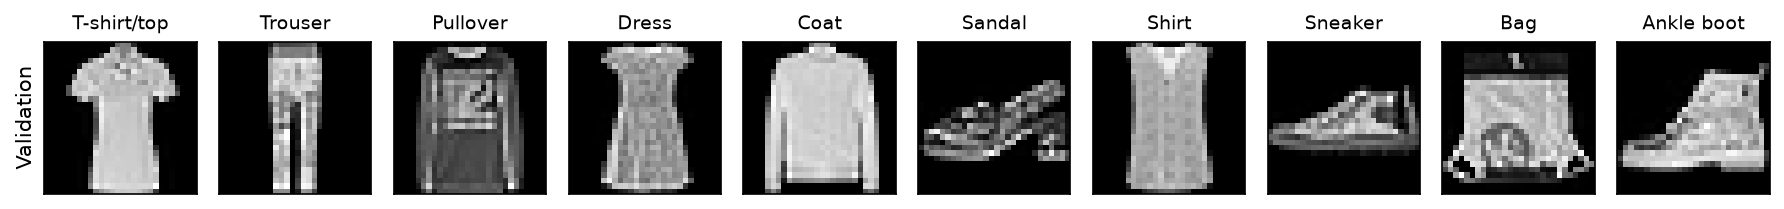

**Expected check:** `50000 / 10000 / 10000`. Explain why a label may color a
scatterplot without being a training target. The same input scaling must be used
for training, reconstruction error, and every displayed image.

## 2 · Task A: build the parameterized autoencoder

Use **784 → 256 → 128 → d → 128 → 256 → 784**. Hidden layers use ReLU;
the latent layer is linear. The output uses Sigmoid, then restores `(N,1,28,28)`.
Define `self.encoder`, `self.decoder`, and `forward`. No path may bypass `z`.

Each arrow is a deterministic transformation, not a probabilistic dependency:

```text
(N,1,28,28) -> Flatten -> (N,784) -> (N,256) -> (N,128)
                                                         |
                                                       (N,d)
                                                         |
(N,1,28,28) <- Unflatten <- (N,784) <- (N,256) <- (N,128)
```

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, d):
        super().__init__()
        # TODO A: define the encoder and decoder specified above.
        raise NotImplementedError('Implement the architecture')

    def forward(self, x):
        # TODO A: encode, then decode; return the reconstructed batch.
        raise NotImplementedError

In [ ]:
for d in DIMS:
    m = Autoencoder(d)
    x = torch.rand(5, 1, 28, 28)
    z, y = m.encoder(x), m(x)
    assert z.shape == (5,d) and y.shape == x.shape
    assert torch.all((y >= 0) & (y <= 1))
    linears = [layer for layer in m.modules() if isinstance(layer, nn.Linear)]
    assert [(l.in_features,l.out_features) for l in linears] == [
        (784,256),(256,128),(128,d),(d,128),(128,256),(256,784)]
    y.sum().backward()
    assert all(p.grad is not None and torch.isfinite(p.grad).all() for p in m.parameters())
print('PASS: all four shapes, ranges, architectures, and gradient paths')

## 3 · Task B: define exactly what the score means

Implement the scalar mean squared error across **all examples and all pixels**:
$L=\frac{1}{ND}\sum_{i,j}(x_{ij}-\hat{x}_{ij})^2$.
Reject different shapes instead of allowing accidental broadcasting.

In [ ]:
def reconstruction_loss(prediction, target):
    # TODO B: equal shapes, scalar mean squared error.
    raise NotImplementedError

In [ ]:
target = torch.tensor([0.,1.,1.,0.]).reshape(1,1,2,2)
prediction = torch.tensor([.1,.8,.6,.2]).reshape_as(target).requires_grad_()
loss = reconstruction_loss(prediction, target)
assert loss.ndim == 0 and torch.allclose(loss, torch.tensor(.0625))
loss.backward()
assert torch.allclose(prediction.grad.flatten(), torch.tensor([.05,-.10,-.20,.10]))
assert torch.allclose(reconstruction_loss(prediction.repeat(3,1,1,1),
                                         target.repeat(3,1,1,1)), loss)
try:
    reconstruction_loss(torch.zeros(2,1,28,28), torch.zeros(1,1,28,28))
except (ValueError, AssertionError):
    pass
else:
    raise AssertionError('Reject broadcastable but unequal shapes')
print('PASS: MSE = 0.0625, gradient correct, batch duplication preserves scale')

## 4 · Provided training infrastructure

`train_model(d)` creates a fresh network and optimizer, trains for the same fixed
budget, and returns the model **at the final epoch** plus its history. It resets
the initialization seed and data-order generator. Changing d still changes parameter
count, so this is a controlled architectural comparison, not identical capacity.
Validation never updates weights. Timing is recorded but is not a benchmark.

In [ ]:
@torch.inference_mode()
def evaluate(model, loader):
    model.eval()
    total, pixels = 0., 0
    for images, _ in loader:
        images = images.to(DEVICE)
        prediction = model(images)
        total += (prediction-images).square().sum().item()
        pixels += images.numel()
    return total / pixels

def train_model(d):
    seed_all(SEED)
    model = Autoencoder(d).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loader = train_loader()
    history = []
    start = time.perf_counter()
    for epoch in range(EPOCHS):
        model.train()
        total, count = 0., 0
        for images, _ in loader:
            images = images.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = reconstruction_loss(model(images), images)
            loss.backward()
            optimizer.step()
            total += loss.item() * len(images)
            count += len(images)
        row = dict(epoch=epoch+1, train_mse=total/count,
                   val_mse=evaluate(model, val_loader))
        history.append(row)
        print(f'd={d:3d} epoch={epoch+1}/{EPOCHS} val_mse={row["val_mse"]:.5f}')
    history[-1]['seconds'] = time.perf_counter()-start
    torch.save({k:v.detach().cpu() for k,v in model.state_dict().items()}, CHECKPOINT_DIR/f'ae-d{d}.pt')
    return model.eval(), history

## 5 · Task C: sweep d and compare the same images

Train one **independent** model for each entry in `DIMS`. Fill `models[d]` and
`histories[d]` with the corresponding returned objects. Do not reuse the final
model or fine-tune one width from another. Restore six epochs after debugging.

In [ ]:
models, histories = {}, {}
# TODO C: loop through DIMS and store each model and its history.
raise NotImplementedError('Implement the dimension sweep')

In [ ]:
assert set(models) == set(histories) == set(DIMS)
assert len({id(model) for model in models.values()}) == len(DIMS)
assert all(len(histories[d]) == EPOCHS for d in DIMS)
comparison = [dict(d=d, parameters=sum(p.numel() for p in models[d].parameters()),
                   val_mse=histories[d][-1]['val_mse'], coordinates= d/784)
              for d in DIMS]
print(json.dumps(comparison, indent=2))
(OUT/'metrics.json').write_text(json.dumps(dict(seed=SEED, epochs=EPOCHS,
    train_size=len(train_set), val_size=len(val_set), device=str(DEVICE),
    torch_version=torch.__version__, comparison=comparison, histories=histories), indent=2))

fig, axes = plt.subplots(1,2,figsize=(12,4))
for d in DIMS:
    axes[0].plot(range(1,EPOCHS+1), [h['val_mse'] for h in histories[d]], label=f'd={d}')
axes[0].set(xlabel='Epoch', ylabel='Validation MSE'); axes[0].legend()
axes[1].plot(DIMS, [r['val_mse'] for r in comparison], 'o-')
axes[1].set_xscale('log',base=2); axes[1].set_xticks(DIMS, labels=DIMS)
axes[1].set(xlabel='Latent dimension', ylabel='Final validation MSE')
savefig(fig, 'curves.png')

examples = torch.stack(audit).to(DEVICE)
with torch.inference_mode():
    rows = [examples.cpu()] + [models[d](examples).cpu() for d in DIMS]
image_grid(rows, ['Original']+[f'd={d}' for d in DIMS], class_names, 'reconstructions.png')

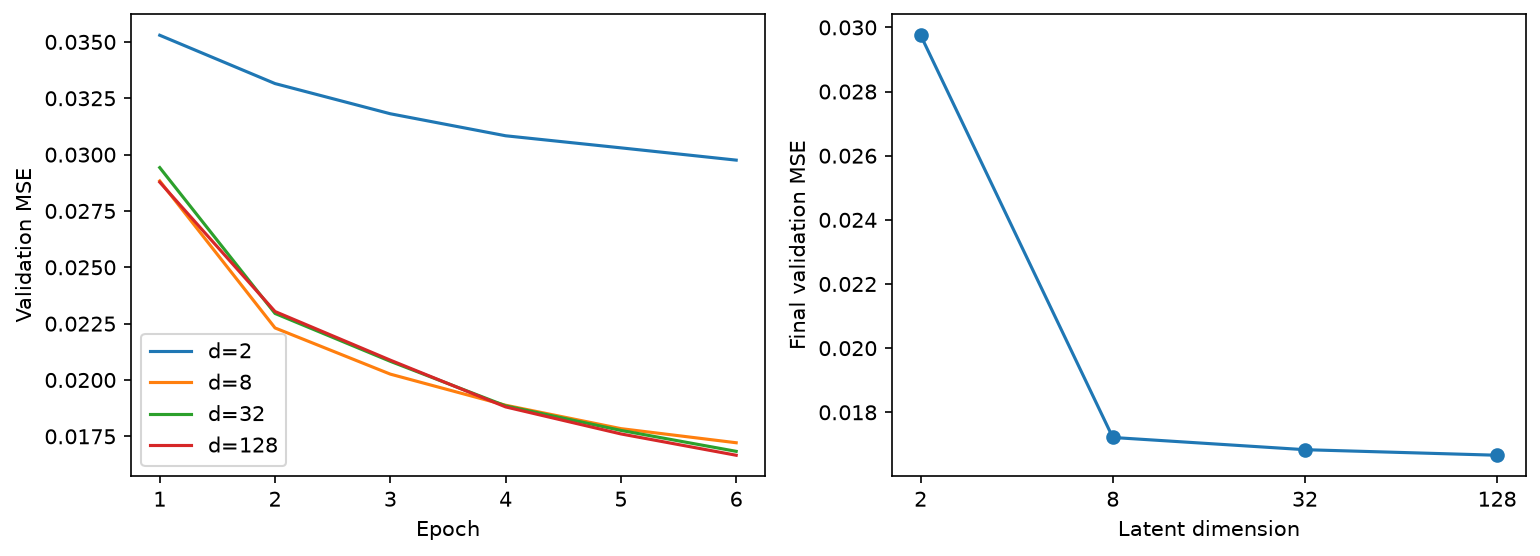

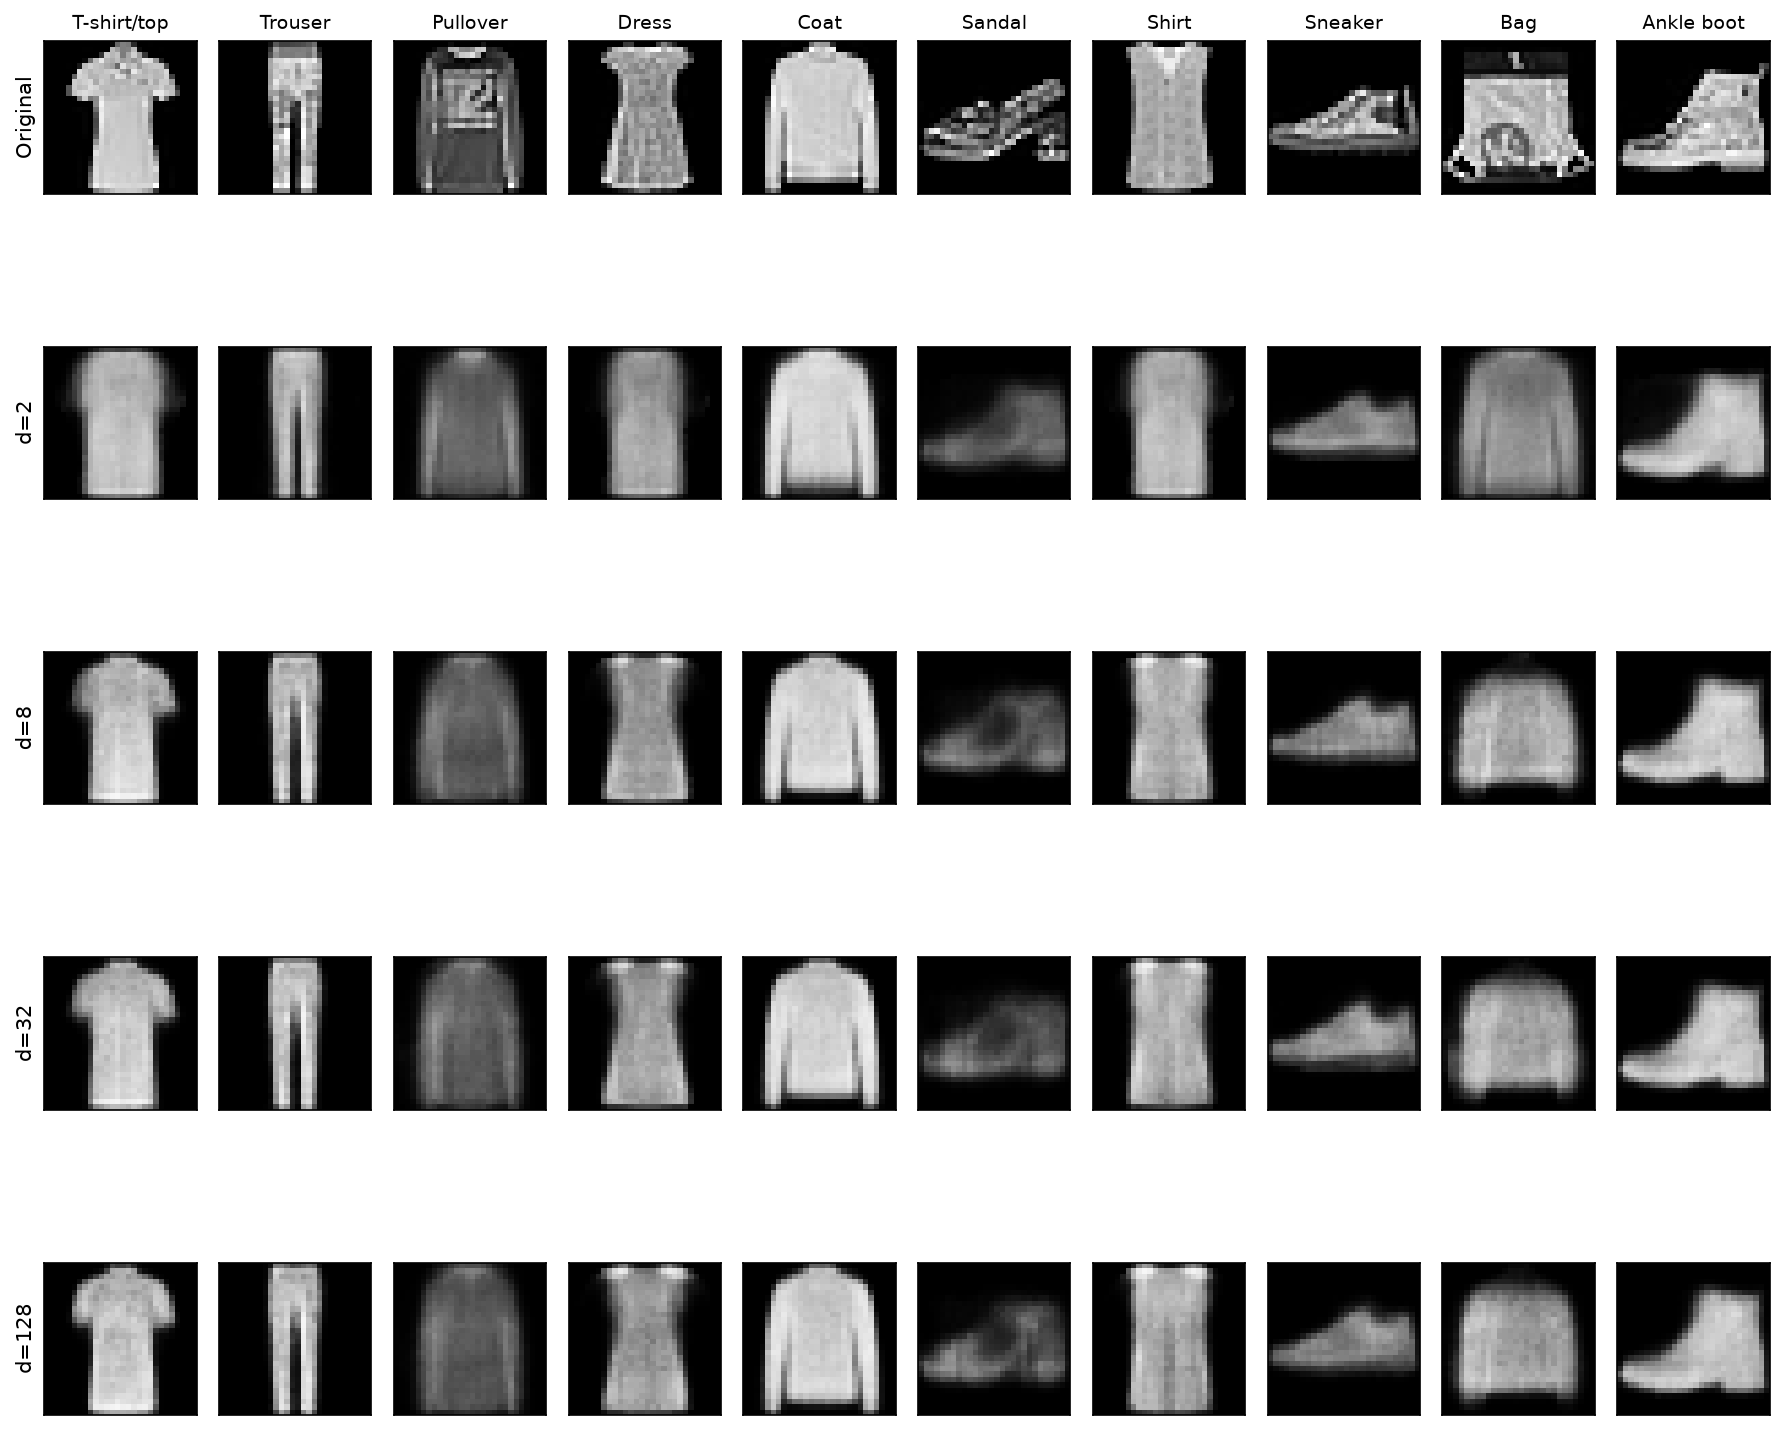

**Interpretation to check:** coarse outlines often improve before texture; gains
can plateau and need not be strictly monotone. Exact losses depend on the run.
Look at thin structures and ambiguous tops, not just the easiest example.
These results use a new 50,000/10,000 split and therefore differ from lecture numbers.

### Investigation 1 · Your evidence

1. Explain which details survive at d=2 and which are recovered at larger d.
2. Calculate the relative validation improvement from 2 to 8 and from 32 to 128.
3. Choose a provisional d based on both error and visual evidence. Explain the cost.
4. For d=32, compare 784 uint8 pixels with 32 float32 coordinates. Include the
   decoder-storage caveat: coordinate reduction is not a measured file-compression ratio.

**Write your interpretation here.**

## 6 · Provided encoding and projection infrastructure

We inspect a fixed set of 1,000 validation images (100 per class). For d=2 the
plot shows the **actual code**. For d>2, provided SVD-based PCA centers this
inspection sample and projects it onto two directions of largest variance.
PCA is a display tool here, not a student implementation task or a replacement
for the trained encoder. Its explained-variance fraction reports what the display retains.

Neighbor distances are always calculated in the **original d-dimensional code**.
Projection can hide separations, and PCA signs/orientation can flip between runs.
Do not compare absolute distances or axis directions across independently trained models.

In [ ]:
@torch.inference_mode()
def encode_dataset(model, loader):
    model.eval()
    images, codes, labels, recon = [], [], [], []
    for x,y in loader:
        z = model.encoder(x.to(DEVICE))
        codes.append(z.cpu()); recon.append(model.decoder(z).cpu())
        images.append(x); labels.append(y)
    return dict(x=torch.cat(images), z=torch.cat(codes),
                y=torch.cat(labels), reconstruction=torch.cat(recon))

def project_for_display(z):
    if z.shape[1] == 2:
        return z.numpy(), 'Actual z₁ and z₂ (not a projection)'
    centered = z - z.mean(0,keepdim=True)
    _, singular, vh = torch.linalg.svd(centered, full_matrices=False)
    variance = (singular[:2].square().sum()/singular.square().sum()).item()
    return (centered @ vh[:2].T).numpy(), f'PCA display: {variance:.1%} variance retained'

encoded = {d:encode_dataset(models[d], inspect_loader) for d in DIMS}
displays = {d:project_for_display(encoded[d]['z']) for d in DIMS}
fig, axes = plt.subplots(2,2,figsize=(12,9))
for ax,d in zip(axes.flat,DIMS):
    xy, label = displays[d]
    ax.scatter(xy[:,0],xy[:,1],c=encoded[d]['y'],cmap='tab10',vmin=-.5,vmax=9.5,s=8,alpha=.65)
    ax.set_title(f'd={d}: {label}', fontsize=11)
    ax.set(xlabel='Coordinate 1' if d==2 else 'PC1', ylabel='Coordinate 2' if d==2 else 'PC2')
fig.legend([plt.Line2D([],[],marker='o',ls='',color=plt.cm.tab10(k)) for k in range(10)],
           class_names, loc='lower center', ncol=5,fontsize=9)
fig.tight_layout(rect=(0,.07,1,1)); savefig(fig,'maps.png')

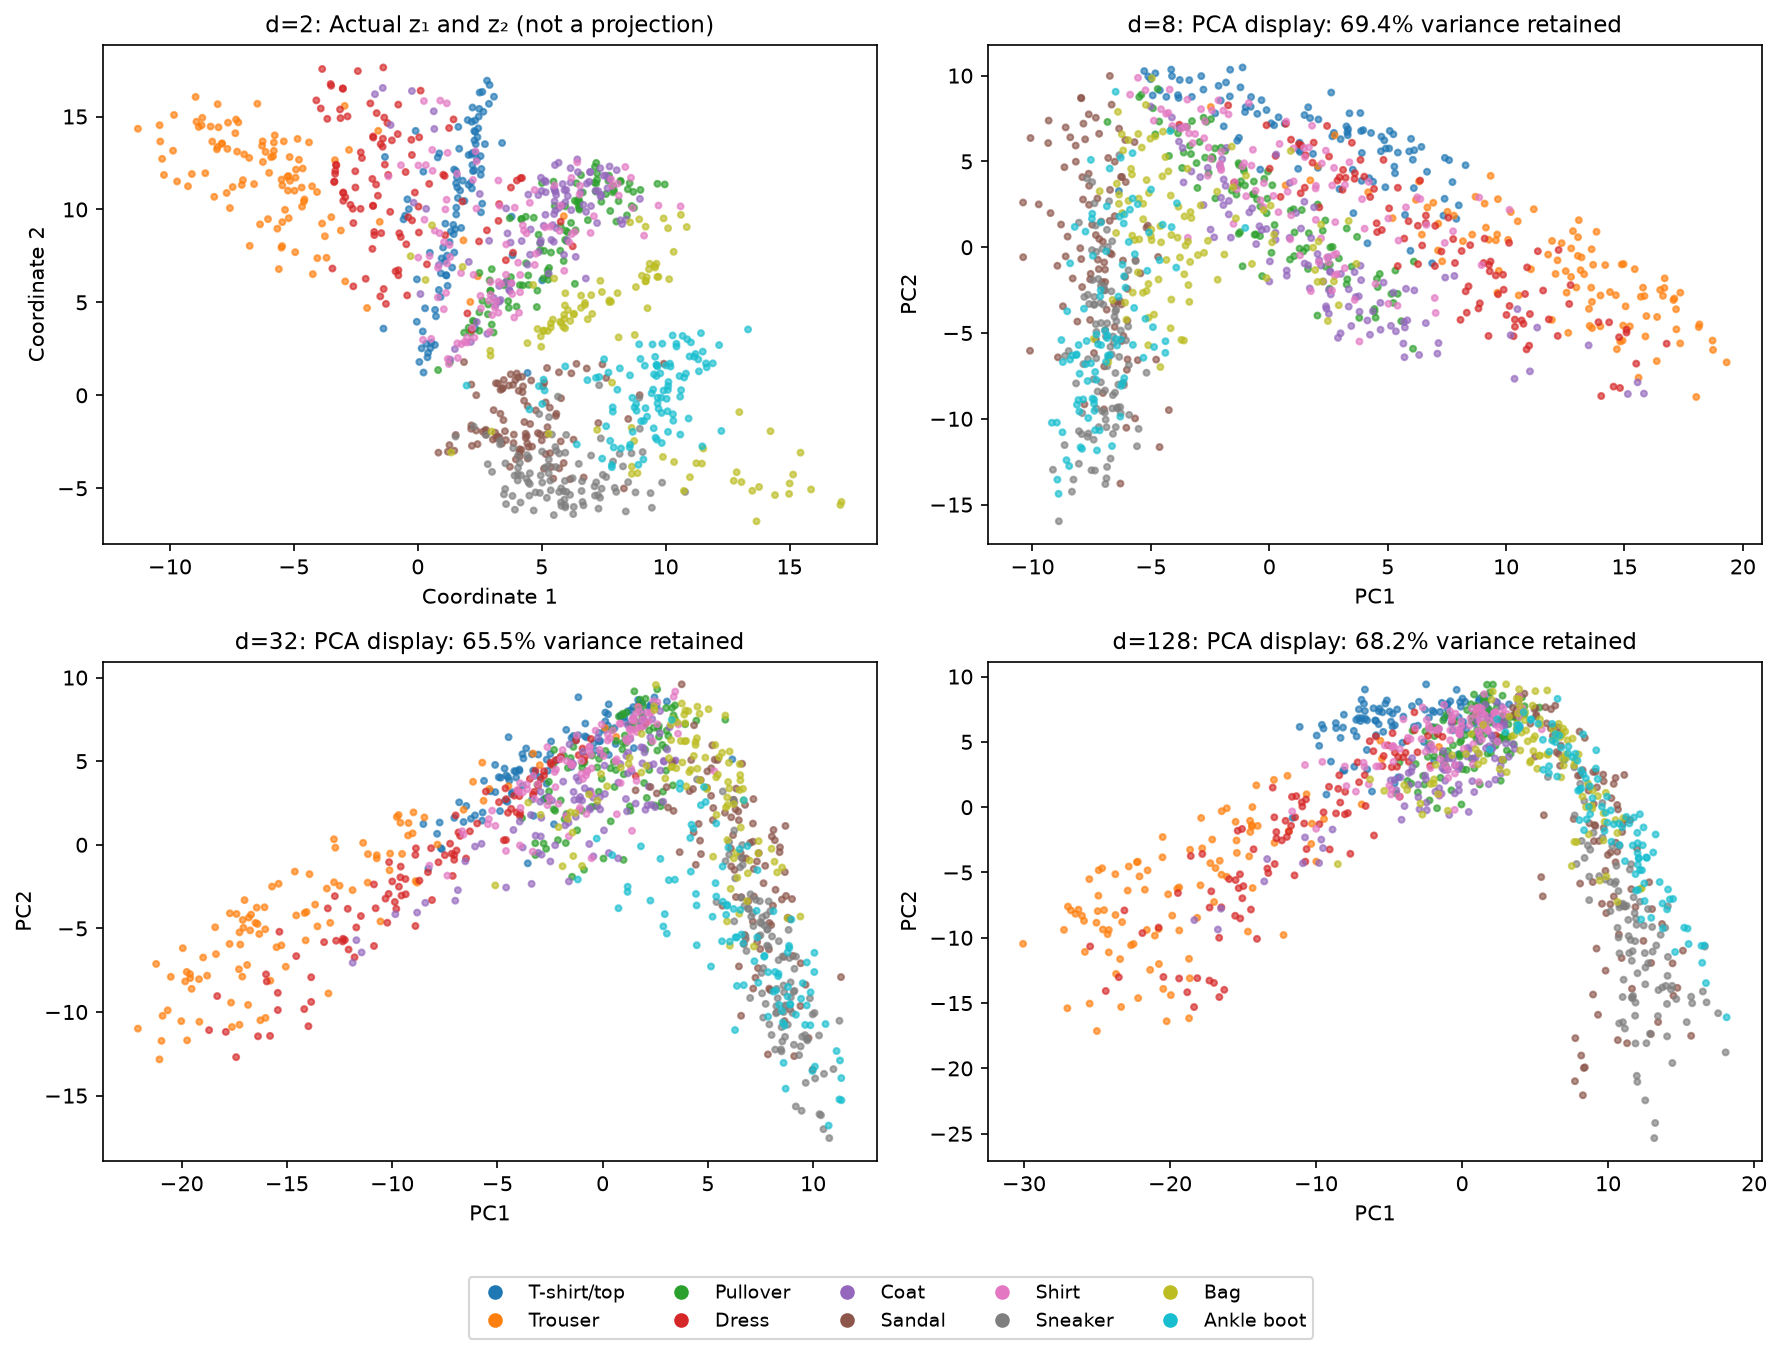

**Expected observation:** labels can align with some regions without forming ten
clean clusters. A small PCA variance fraction warns that the display omits much
of the original representation. Apparent overlap alone does not establish overlap in d dimensions.

## 7 · Task D: find neighbors in the real code

Given a code tensor `(M,d)` and an anchor index, return the indices of the k
nearest **other** examples under Euclidean distance. Exclude the anchor itself,
preserve distinct examples, and return increasing distance order.

In [ ]:
def nearest_neighbors(z, anchor, k=7):
    # TODO D: distances in all d coordinates; exclude anchor; sort.
    raise NotImplementedError

In [ ]:
probe = torch.tensor([[0.,0.,0.],[.01,0.,100.],[1.,0.,0.],[2.,0.,0.]])
assert torch.equal(nearest_neighbors(probe,0,k=2), torch.tensor([2,3]))
print('PASS: anchor excluded; all latent coordinates used')

def neighbor_panel(d, anchor=600, save_name='neighbors.png'):
    e = encoded[d]
    indices = [anchor] + nearest_neighbors(e['z'],anchor).tolist()
    distances = (e['z'][indices]-e['z'][anchor]).norm(dim=1)
    titles = ['Anchor'] + [f'{class_names[e["y"][i]]}\n{distances[j]:.2f}'
                           for j,i in enumerate(indices) if j>0]
    image_grid([e['x'][indices],e['reconstruction'][indices]],
               ['Input','Reconstruction'], titles, save_name)

neighbor_panel(2,600)
neighbor_panel(32,600,'neighbors-d32.png')

# Optional interactive control; static calls above work without widgets.
try:
    from ipywidgets import interact, IntSlider, FloatSlider, Dropdown
    from IPython.display import display
    import ipywidgets as widgets
    try:
        from google.colab import output
        output.enable_custom_widget_manager()
    except ImportError:
        pass
    def inspect_anchor(d=2, anchor=600):
        xy, title = displays[d]
        neighbors = nearest_neighbors(encoded[d]['z'], anchor)
        fig,ax = plt.subplots(figsize=(7,4))
        ax.scatter(xy[:,0],xy[:,1],c=encoded[d]['y'],cmap='tab10',vmin=-.5,vmax=9.5,s=8,alpha=.4)
        ax.scatter(*xy[anchor],marker='*',s=180,c='black',label='Anchor')
        ax.scatter(xy[neighbors,0],xy[neighbors,1],facecolors='none',edgecolors='black',s=60,label='Raw-code neighbors')
        ax.set_title(title); ax.legend(); plt.show(); plt.close(fig)
        neighbor_panel(d,anchor,'neighbors-selected.png')
    interact(inspect_anchor, d=Dropdown(options=DIMS,value=2),
             anchor=IntSlider(min=0,max=999,value=600,continuous_update=False))
except ImportError:
    print('Install ipywidgets for controls; use neighbor_panel(d, anchor) otherwise.')

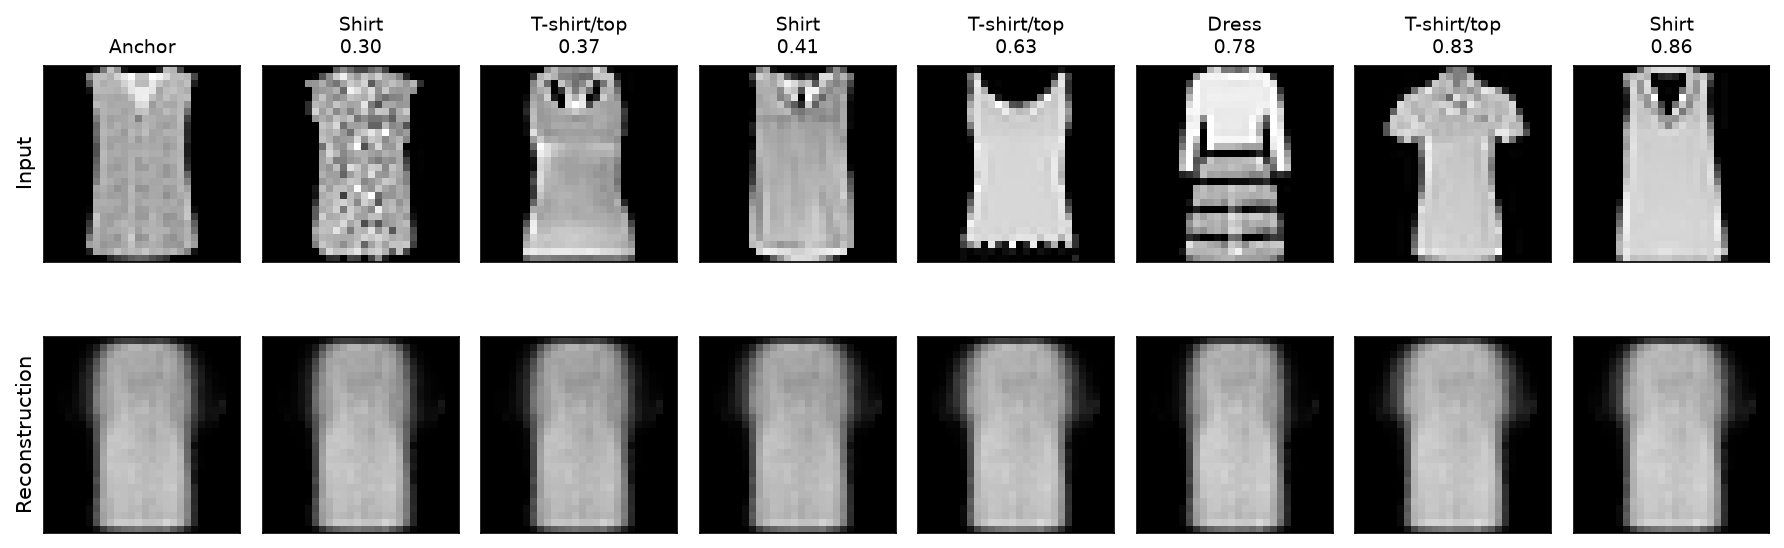

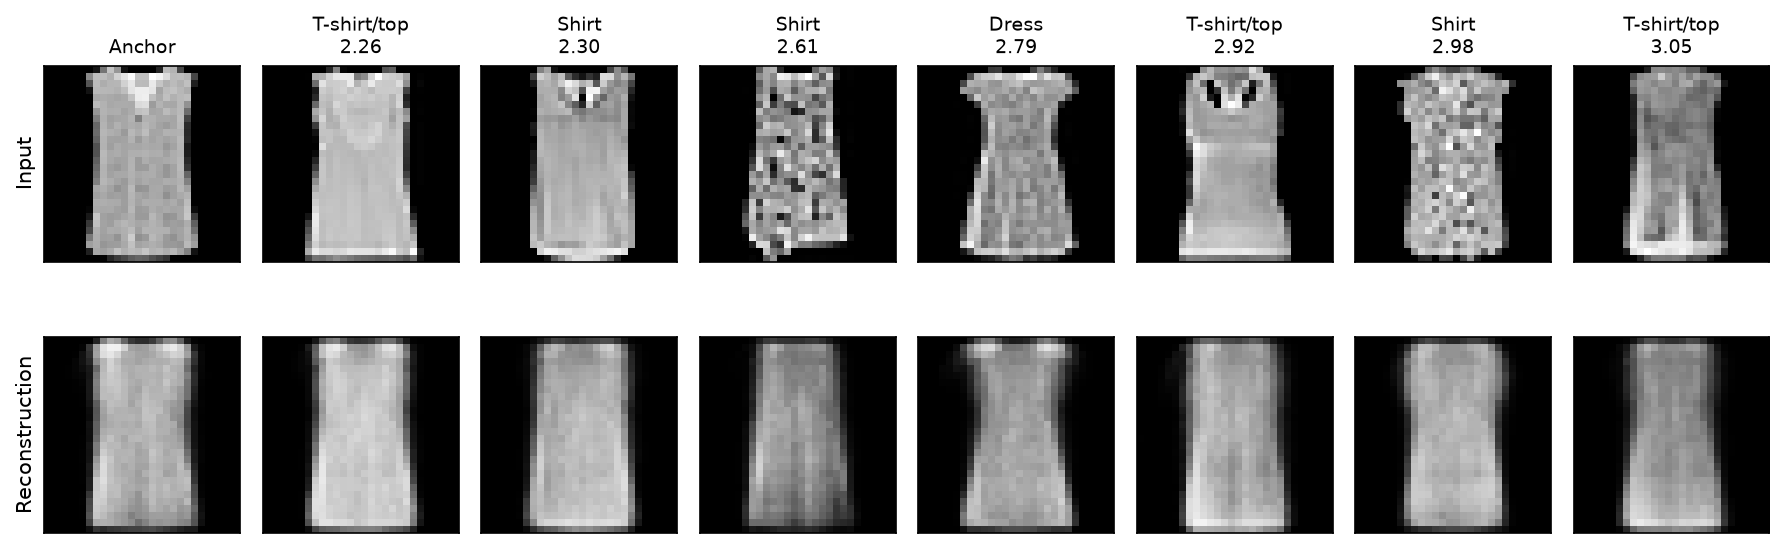

**Expected check:** the toy neighbor test returns `[2, 3]`. In the real galleries,
inspect both class and visual properties; different labels can share silhouette.
Reconstruction can smooth away differences still visible in the originals.

### Investigation 2 · Your evidence

Select two anchors in different classes. Compare their seven neighbors at d=2
and d=32 using the same inspection set. For each anchor report the fraction of
neighbors sharing its class, then explain what that fraction misses visually.
This is a descriptive check on two chosen examples, not a classifier accuracy.
Find one apparent PCA overlap and inspect whether raw-space neighbors support it.

**Write your interpretation here.**

## 8 · Task E: interpolate codes, then decode

For endpoint codes $z_a=f(x)$ and $z_b=f(y)$, implement
$z_\alpha=(1-\alpha)z_a+\alpha z_b$ with $\alpha\in[0,1]$.
Here alpha=0 returns the first endpoint and alpha=1 the second. Reversing this
convention is valid if you document it, but use this convention for the checks.

Return a tensor of shape `(number_of_alphas,d)`. Then compare decoded latent
interpolation with direct pixel blending $(1-\alpha)x+\alpha y$.
At the endpoints, decoded images are reconstructions—not the original inputs.

In [ ]:
def interpolate_codes(z_a, z_b, alphas):
    # TODO E: broadcast alphas over coordinates; preserve dtype and device.
    raise NotImplementedError

In [ ]:
za = torch.tensor([1.,3.,-2.],device=DEVICE)
zb = torch.tensor([5.,-1.,4.],device=DEVICE)
path = interpolate_codes(za,zb,[0.,.5,1.])
assert path.shape == (3,3) and path.device == za.device
assert torch.allclose(path[0],za) and torch.allclose(path[-1],zb)
assert torch.allclose(path[1],(za+zb)/2)
assert torch.allclose(interpolate_codes(za,za,[.1,.8]),za.expand(2,-1))
print('PASS: endpoints, midpoint, identical-endpoint path, shape, and device')

@torch.inference_mode()
def interpolation_panel(d, first, second, name, steps=9):
    model = models[d].eval()
    x,y = encoded[d]['x'][[first,second]].to(DEVICE)
    z_a,z_b = model.encoder(torch.stack([x,y]))
    alphas = torch.linspace(0,1,steps,device=DEVICE)
    decoded = model.decoder(interpolate_codes(z_a,z_b,alphas)).cpu()
    pixels = ((1-alphas[:,None,None,None])*x + alphas[:,None,None,None]*y).cpu()
    assert torch.allclose(decoded[0],model(x[None])[0].cpu(),atol=1e-6)
    assert torch.allclose(decoded[-1],model(y[None])[0].cpu(),atol=1e-6)
    image_grid([decoded,pixels],['Decode latent path','Blend pixels'],
               [f'α={a:.2f}' for a in alphas.cpu()],name)

# Balanced subset order: [0:100] T-shirt, ... [700:800] sneaker, [900:1000] boot.
interpolation_panel(32,700,701,'same-class.png')
interpolation_panel(32,700,900,'cross-class.png')
interpolation_panel(2,700,701,'same-class-d2.png')
interpolation_panel(2,700,900,'cross-class-d2.png')

@torch.inference_mode()
def show_alpha(d=32, first=700, second=900, alpha=.5):
    model = models[d].eval()
    x,y = encoded[d]['x'][[first,second]].to(DEVICE)
    za,zb = model.encoder(torch.stack([x,y]))
    decoded = model.decoder(interpolate_codes(za,zb,[alpha]))[0].cpu()
    blend = ((1-alpha)*x+alpha*y).cpu()
    image_grid([[x.cpu(),decoded,blend,y.cpu()]],[''],
               ['Original A',f'Decode at α={alpha:.2f}','Pixel blend','Original B'],
               'slider-selected.png')

try:
    interact(show_alpha, d=Dropdown(options=DIMS,value=32),
             first=IntSlider(min=0,max=999,value=700,continuous_update=False),
             second=IntSlider(min=0,max=999,value=900,continuous_update=False),
             alpha=FloatSlider(min=0,max=1,step=.05,value=.5,continuous_update=False))
except NameError:
    show_alpha()  # static fallback if widgets are unavailable

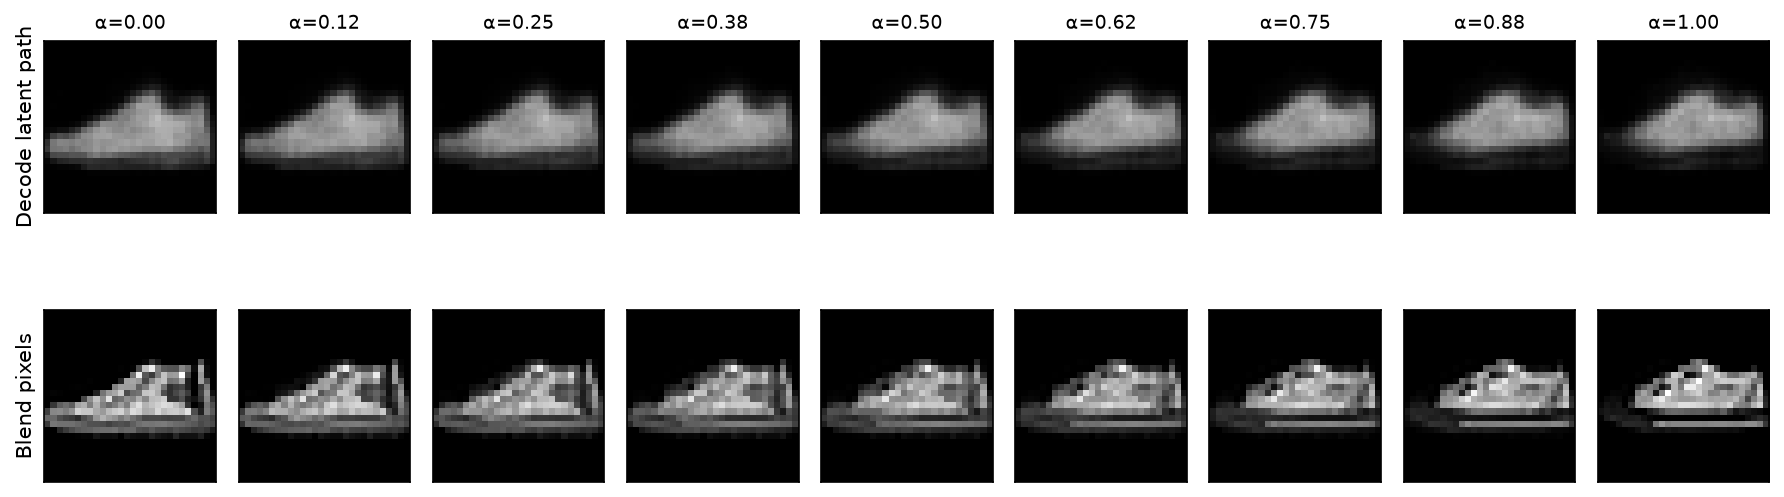

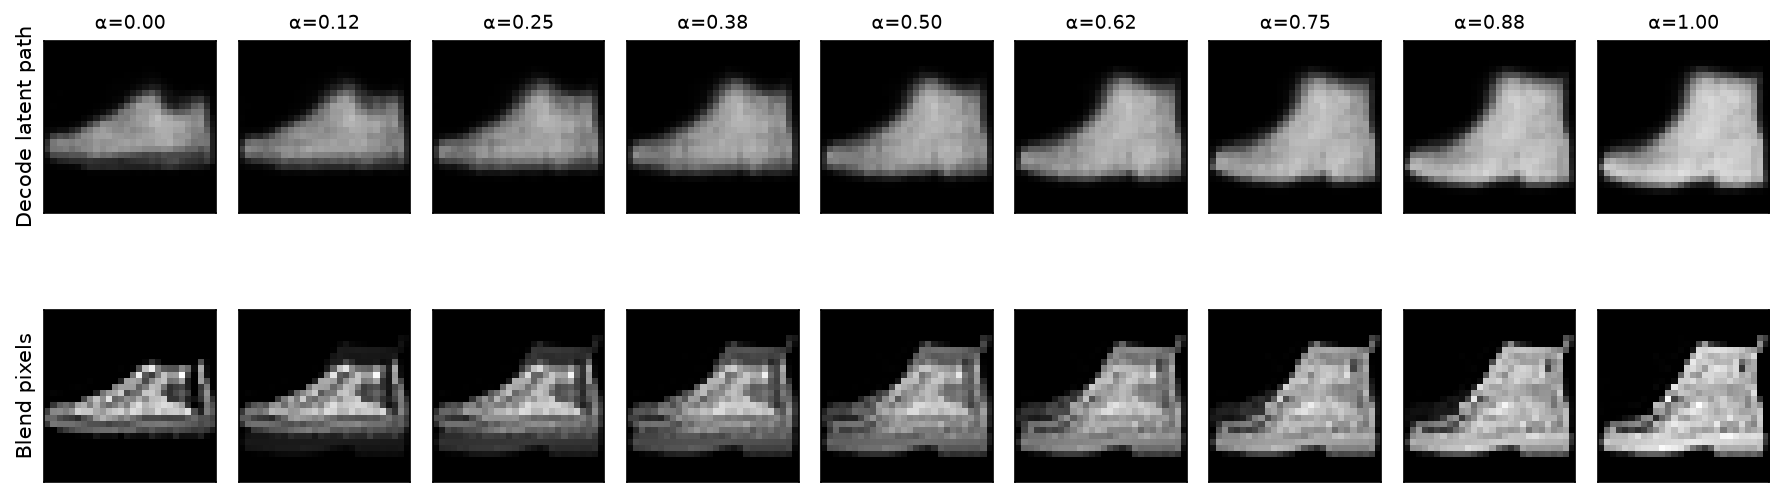

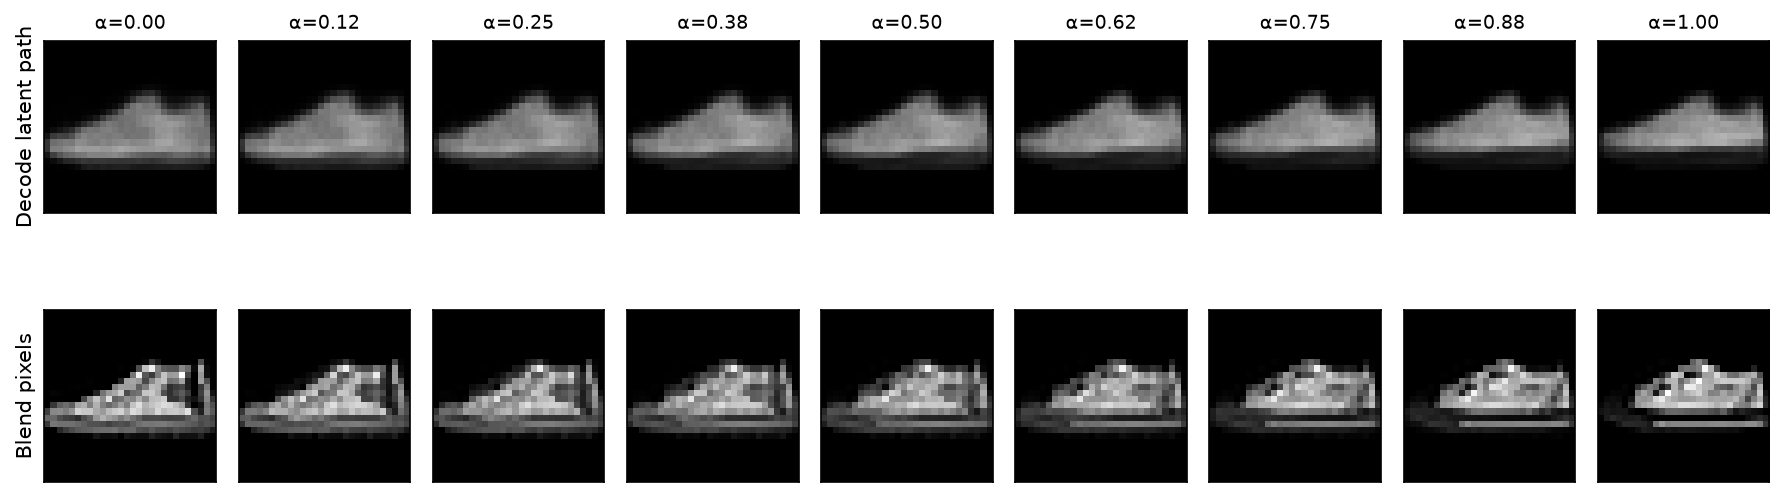

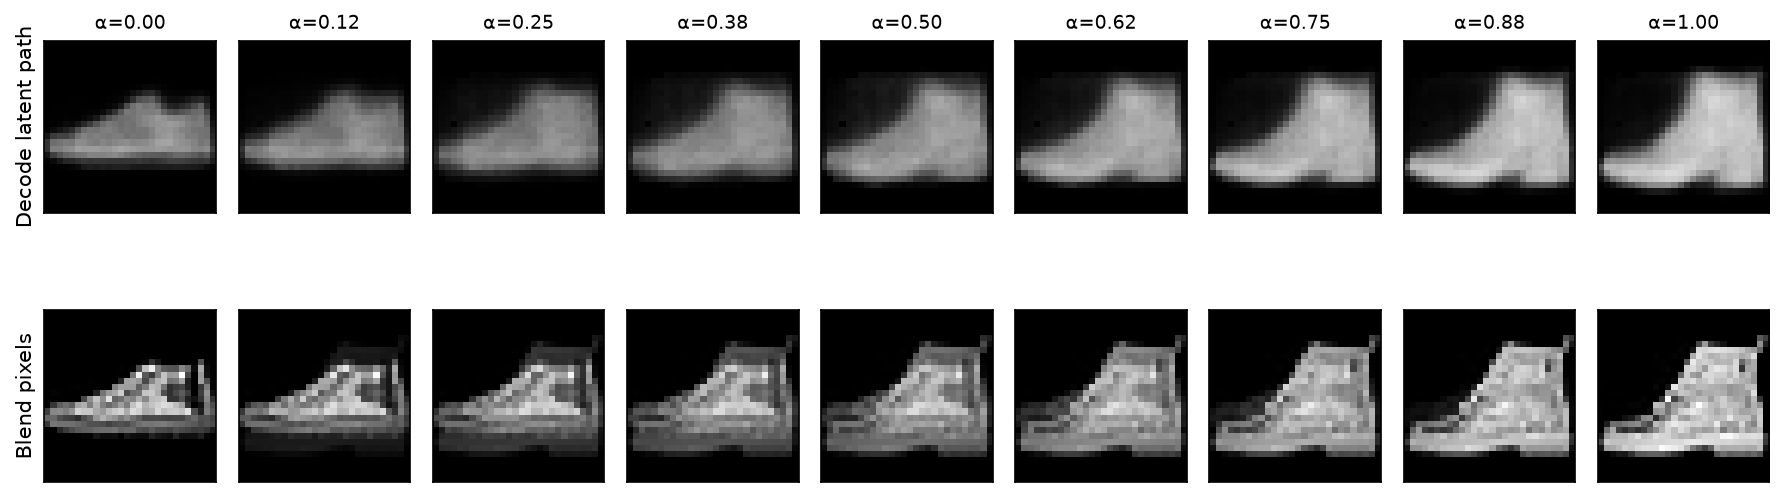

**Expected check:** alpha endpoints equal endpoint reconstructions. A latent path
need not equal a pixel blend. It may change shape coherently or pass through
blurred, ambiguous objects. Smoothness is not evidence that every point is realistic.

### Investigation 3 · Your evidence

Choose one same-class pair and one different-class pair (you may replace the defaults).
Show original endpoints and nine interpolation steps for d=2 and your chosen larger d.
Keep the pixel-blend baseline. Name the pair IDs and classes, describe at least two
intermediate alpha values, and identify a successful or failed transition using visible
shape evidence. Explain why the two paths can disagree and why smooth outputs do
not establish reliable generation from arbitrary random codes.

**Write your interpretation here.**

## 9 · Freeze your choice, then evaluate once

Select d from your validation investigations and record a short reason **before**
running the next cell. Do not tune after inspecting test MSE. Replace the example
choice if your evidence supports another dimension.

In [ ]:
chosen_d = 8
selection_reason = ''  # TODO: justify using validation evidence before final testing.
assert chosen_d in models and selection_reason.strip(), 'Record your reason first'
final_test_loader = DataLoader(test_set,batch_size=512,shuffle=False)
final_test_mse = evaluate(models[chosen_d], final_test_loader)
final = dict(chosen_d=chosen_d, reason=selection_reason, test_mse=final_test_mse)
(OUT/'final-evaluation.json').write_text(json.dumps(final,indent=2))
print(final)

## Submission

Submit the executed notebook and a short report (about 2–4 pages) containing:

- all public checks passing after Restart & Run All;
- the training configuration and split, validation table/curves, and fixed-image gallery;
- two anchor investigations at d=2 and d=32, with raw-space neighbor evidence;
- two endpoint pairs, nine-step latent paths at two dimensions, and pixel baselines;
- your validation-based dimension choice, frozen reason, and one final test score;
- one limitation or failure supported by your own images, not a generic sentence.

Figures and metrics are saved under `latent-results/` (or `COURSE_OUTPUT_DIR`).
Keep checkpoints locally; do not upload the Fashion-MNIST data. GPU speed is not graded.
PCA and widget implementation are provided; gradeable work is the model, loss,
sweep, neighbor search, interpolation, and interpretation. No VAE or GAN is required.

### Readings

- [Chapter 10 notes](https://anassbelcaid.github.io/deeplearning-course/notes/10-autoencoders-latent-representations/)
- [Fashion-MNIST paper](https://arxiv.org/abs/1708.07747)
- [Deep Learning, Chapter 14](https://www.deeplearningbook.org/contents/autoencoders.html)